# Regression Trees on Brainvita (From Scratch)

This notebook uses the custom `rice_ml.supervised_learning.RegressionTree` to predict `num_legal_moves` directly.

A regression tree is the nonlinear counterpart to the OLS baseline. Instead of fitting one global line, it partitions the feature space into regions and predicts the average legal-move count in each leaf. That makes it useful for Brainvita because local board structure can interact in ways a linear model cannot capture.

## Learning Objectives

1. Explain how a regression tree chooses splits by reducing target variance.
2. Use the shared Brainvita feature matrix to predict continuous legal-move count.
3. Compare the tree against a mean predictor baseline.
4. Evaluate R2, MSE, RMSE, and MAE on train and test splits.
5. Use predicted-vs-actual and residual plots to identify where piecewise-constant predictions help or fall short.


## Dataset and Target

The target is `num_legal_moves`, the same continuous mobility score used in the linear regression notebook. We keep the same curated feature set and exclude raw `board_state` plus best/worst move-coordinate fields to avoid leakage.

Regression trees do not need feature standardization because they split on one feature threshold at a time. Keeping raw feature units also makes split logic easier to understand.

## 1. Mathematical Intuition

Regression trees partition feature space into regions and predict the mean target in each leaf.

Split criterion minimizes weighted variance (MSE):

$$
\text{Score} = \frac{n_L}{n} \operatorname{Var}(y_L) + \frac{n_R}{n} \operatorname{Var}(y_R)
$$


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt


def find_repo_root(start='.'):
    p = Path(start).resolve()
    for q in [p, *p.parents]:
        if (q / 'src' / 'rice_ml').exists() and (q / 'data' / 'brainvita_dataset.csv').exists():
            return q
    raise FileNotFoundError('Could not locate repository root')


ROOT = find_repo_root('.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

DATA_PATH = ROOT / 'data' / 'brainvita_dataset.csv'
print('Repo root:', ROOT)
print('Dataset path:', DATA_PATH)

from rice_ml.supervised_learning import RegressionTree

Repo root: /Users/LakshSarda/Desktop/CMOR_438_Repository
Dataset path: /Users/LakshSarda/Desktop/CMOR_438_Repository/data/brainvita_dataset.csv


The setup output confirms the notebook resolved the repository root and dataset path. The Matplotlib font-cache line is just an environment message, while the printed path confirms the notebook is reading the intended Brainvita CSV before sampling and fitting the tree.

In [2]:
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    header = f.readline().strip().split(',')

exclude_cols = {
    'num_legal_moves',
    'board_state',
    'best_move_r1', 'best_move_c1', 'best_move_r2', 'best_move_c2',
    'worst_move_r1', 'worst_move_c1', 'worst_move_r2', 'worst_move_c2',
}

raw_feature_cols = [c for c in header if c not in exclude_cols]
selected_cols = raw_feature_cols + ['num_legal_moves']
selected_idx = [header.index(c) for c in selected_cols]
arr = np.loadtxt(DATA_PATH, delimiter=',', skiprows=1, usecols=selected_idx, dtype=float)

X_raw = arr[:, :-1]
y_reg = arr[:, -1]
y_bin = (y_reg >= 3.0).astype(int)

preferred_features = ['peg_ratio', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster', 'avg_adjacent_pegs', 'avg_adjacent_empty', 'max_adjacent_empty', 'center_of_mass_r', 'center_of_mass_c', 'spread', 'min_pegs_reachable', 'max_pegs_reachable', 'board_rows', 'board_cols']
feature_cols = [c for c in preferred_features if c in raw_feature_cols]
keep_idx = [raw_feature_cols.index(c) for c in feature_cols]
X = X_raw[:, keep_idx]

# Reproducible subset for notebook runtime while preserving methodology.
rng_sample = np.random.default_rng(42)
sample_n = min(12000, X.shape[0])
sel = rng_sample.choice(X.shape[0], size=sample_n, replace=False)
X = X[sel]
y_reg = y_reg[sel]
y_bin = y_bin[sel]
print('Using sampled rows for notebook execution:', X.shape[0])

print(f'Rows: {X.shape[0]:,} | Features: {X.shape[1]}')
print('Positive class rate (num_legal_moves >= 3):', float(y_bin.mean()))
print('Features used:', feature_cols)

y_target = y_reg

Using sampled rows for notebook execution: 12000
Rows: 12,000 | Features: 15
Positive class rate (num_legal_moves >= 3): 0.28675
Features used: ['peg_ratio', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster', 'avg_adjacent_pegs', 'avg_adjacent_empty', 'max_adjacent_empty', 'center_of_mass_r', 'center_of_mass_c', 'spread', 'min_pegs_reachable', 'max_pegs_reachable', 'board_rows', 'board_cols']


The loading output confirms this notebook uses a 12,000-row sample with 15 engineered features. The printed positive-class rate of `0.28675` is only context from the shared Brainvita framing; this notebook's actual target is the continuous `num_legal_moves` value.

The sample size should be kept in mind when reading the results. The regression tree metrics below describe this sampled execution, not an evaluation over every row in the full CSV.

## 2. Split Data

The split uses a fixed random seed so results are reproducible. No scaling is applied because variance-reduction splits are unaffected by whether a feature is measured in counts, ratios, or board-coordinate units.

In [3]:
rng = np.random.default_rng(42)
idx = np.arange(X.shape[0])
rng.shuffle(idx)

split = int(0.8 * len(idx))
train_idx, test_idx = idx[:split], idx[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_target[train_idx], y_target[test_idx]

print('Train samples:', X_train.shape[0], '| Test samples:', X_test.shape[0])


Train samples: 9600 | Test samples: 2400


The split output confirms 9,600 training samples and 2,400 test samples. The target for this notebook is the raw legal-move count, so the later metrics should be read as regression metrics rather than classification metrics.

As with the decision tree classifier, no feature scaling is needed for the tree's threshold splits. The important observed fact is that evaluation happens on a held-out test subset of the sampled rows.

## 3. Train Regression Tree and Compare Baseline

The mean predictor is the required first comparison: it always predicts the training-set average legal-move count. The regression tree should reduce RMSE and MAE relative to that baseline while keeping train and test scores close enough to avoid obvious overfitting.

In [4]:
model = RegressionTree(max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42)
model.fit(X_train, y_train)
print('Model:', model.__class__.__name__)
print('n_features_in_:', model.n_features_in_)


Model: RegressionTree
n_features_in_: 15


The model output confirms that the fitted estimator is a `RegressionTree` and that it received 15 input features. This matches the feature list printed during loading.

This cell is a sanity check before evaluating the regression. It confirms the model was fit with the intended feature matrix, but it does not by itself tell us whether the tree predicts legal-move count well.

In [5]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = float(np.mean((y_true - y_pred) ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
    return {'r2': r2, 'mse': mse, 'rmse': rmse, 'mae': mae}

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
mean_pred = np.full_like(y_test, y_train.mean(), dtype=float)

rows = [
    ('Mean baseline', regression_metrics(y_test, mean_pred)),
    ('Tree train', regression_metrics(y_train, y_pred_train)),
    ('Tree test', regression_metrics(y_test, y_pred_test)),
]

print('Regression tree comparison')
print('-' * 84)
print(f"{'Model':<18}{'R2':>12}{'MSE':>14}{'RMSE':>14}{'MAE':>14}")
print('-' * 84)
for name, metrics in rows:
    print(f"{name:<18}{metrics['r2']:>12.4f}{metrics['mse']:>14.4f}{metrics['rmse']:>14.4f}{metrics['mae']:>14.4f}")
print('-' * 84)


Regression tree comparison
------------------------------------------------------------------------------------
Model                       R2           MSE          RMSE           MAE
------------------------------------------------------------------------------------
Mean baseline          -0.0005        1.1406        1.0680        0.8068
Tree train              0.9891        0.0130        0.1142        0.0250
Tree test               0.9741        0.0295        0.1718        0.0389
------------------------------------------------------------------------------------


The metric table shows a very large improvement over the mean baseline. The baseline has `R2 = -0.0005`, RMSE `1.0680`, and MAE `0.8068`, so it does not explain legal-move count beyond the average.

The tree's test row is much stronger: `R2 = 0.9741`, RMSE `0.1718`, and MAE `0.0389`. The train row is stronger still, with `R2 = 0.9891`, RMSE `0.1142`, and MAE `0.0250`. That train/test difference is worth noting: the model generalizes well on this sample, but it fits the training rows more tightly than the held-out rows.

The test MAE of `0.0389` is especially small in legal-move units. Most predictions are very close to the true count, but the diagnostics are still needed because aggregate metrics can hide structured residual bands.

## 4. Diagnostics

The tree predicts a constant value in each leaf, so the predicted-vs-actual plot often has horizontal bands. That is expected. The residual-vs-predicted plot checks whether some prediction ranges consistently under- or over-estimate legal-move count, and the residual histogram shows how concentrated the errors are around zero.


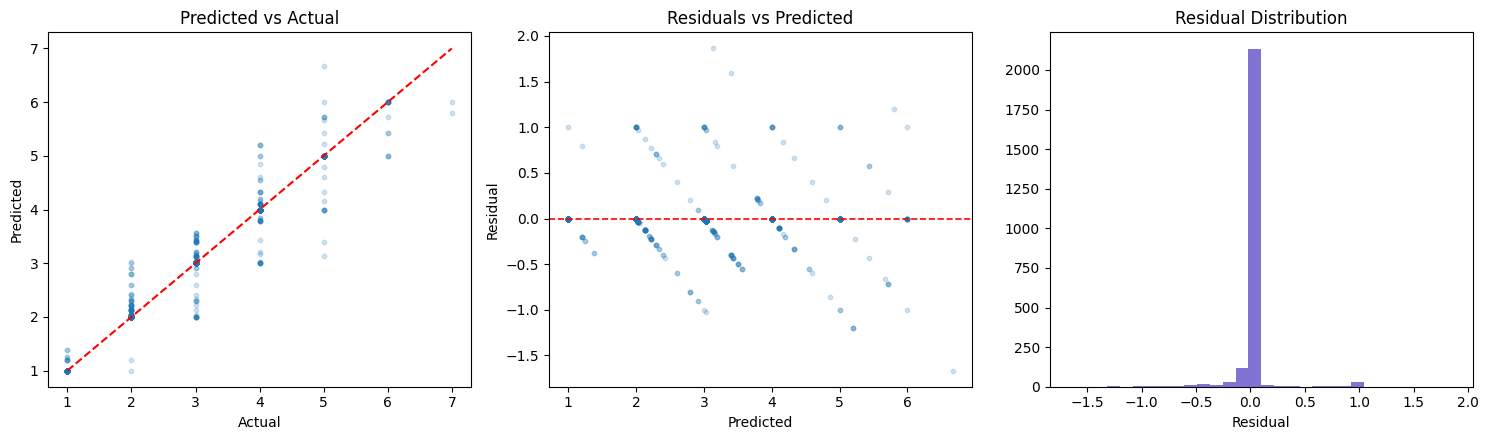

In [6]:
resid = y_test - y_pred_test

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
ax[0].scatter(y_test, y_pred_test, alpha=0.2, s=10)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax[0].plot(lims, lims, 'r--')
ax[0].set_title('Predicted vs Actual')
ax[0].set_xlabel('Actual')
ax[0].set_ylabel('Predicted')

ax[1].scatter(y_pred_test, resid, alpha=0.2, s=10)
ax[1].axhline(0, color='r', linestyle='--', linewidth=1.2)
ax[1].set_title('Residuals vs Predicted')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Residual')

ax[2].hist(resid, bins=30, color='slateblue', alpha=0.85)
ax[2].set_title('Residual Distribution')
ax[2].set_xlabel('Residual')

plt.tight_layout()
plt.show()


The diagnostic plots explain how the tree makes its errors. The predicted-vs-actual panel follows the red diagonal overall, which is consistent with the high test `R2`. The points appear in grouped bands because a regression tree predicts a constant average within each leaf, not a continuously varying formula like OLS.

The residual-vs-predicted panel shows diagonal bands on both sides of zero. That means the residuals are not an unstructured cloud, even though most are small. The histogram confirms that most errors are tightly concentrated near zero, but there are a few larger positive and negative residuals extending out toward roughly one or more moves.

So the plots support a balanced interpretation: the tree is highly accurate on this split, but its piecewise-constant structure is visible in the residuals.

## 5. Conclusion

The regression tree is a strong nonlinear baseline for predicting `num_legal_moves` on the sampled Brainvita data. It improves far beyond the mean predictor: the mean baseline has test `R2 = -0.0005`, while the tree has test `R2 = 0.9741`, RMSE `0.1718`, and MAE `0.0389`.

The train metrics are even stronger than the test metrics, with train `R2 = 0.9891` and train MAE `0.0250`. That gap does not erase the strong test performance, but it does show why tree depth and leaf-size constraints matter. A regression tree can fit very specific board-state regions if it is allowed to grow too freely.

The diagnostic plots show the main limitation. The predictions follow the diagonal overall, and the residual histogram is highly concentrated near zero, but the residual-vs-predicted panel has visible diagonal bands. That structure comes from piecewise-constant leaf predictions and the integer legal-move target. The tree is accurate, but its errors are not pattern-free.
